# Anemia Risk Classification — Complete Machine Learning Pipeline

**Author:** Ahmed Mursal Jamac
**Project:** A Mobile-Based Machine Learning System for Early Anemia Risk Assessment in Low-Resource Settings

This notebook follows the required **13-step machine-learning workflow** end to end,
one step at a time. Eight machine-learning models are trained and compared, and the
class-imbalance problem is addressed with SMOTE.

---

---

**🇸🇴 Sharraxaad Soomaali:**

# Kala-saarista Khatarta Anemia — Marin Buuxa oo Machine Learning

**Qoraa:** Ahmed Mursal Jamac

**Mashruuc:** Nidaam Machine Learning oo Mobile ku salaysan oo lagu qiimeeyo khatarta anemia goor hore, meelaha adeegyadu yar yihiin.

Buug-yarahani (notebook) wuxuu si buuxda u raacayaa **13-ka tallaabo ee loo baahan yahay ee marinka machine learning**, tallaabo-tallaabo. Siddeed (8) model ayaa la tababaray oo la is-barbardhigay, dhibaatada **isku-dheelitirnaan-la'aanta fasalada** waxaa lagu xalliyay **SMOTE**.

## Step 1 — Dataset & Business Problem

**Dataset:** `anemia_master_clean.csv` — demographic, socio-economic and clinical
records (Somalia DHS-derived) for women and children.

**Practical problem.** Anemia (low blood haemoglobin) is widespread in low-resource
settings where laboratory testing is limited. The goal is to build a model that
classifies a person's anemia risk into **Mild, Moderate, or Severe** from routinely
available answers, so that health workers can triage and refer patients early.

**Research questions**
1. Can anemia severity (Mild / Moderate / Severe) be predicted from demographic,
   socio-economic and clinical features?
2. Which machine-learning algorithm gives the best performance among 8 candidates?
3. Does addressing the class imbalance (the rare **Severe** class) improve detection
   of severe cases?

---

**🇸🇴 Sharraxaad Soomaali:**

## Tallaabo 1 — Xogta & Dhibaatada la Xalinayo

**Xogta:** `anemia_master_clean.csv` — diiwaanno demographic, dhaqaale-bulsho iyo caafimaad (laga soo qaatay DHS Soomaaliya) oo haween iyo carruur ah.

**Dhibaatada dhabta ah.** Anemia (dhiig-yaraan / hemoglobin hooseeya) aad bay ugu baahsan tahay meelaha adeegga caafimaadku yar yahay ee baaritaanka shaybaadhku ku kooban yahay. Ujeeddadu waa in la dhiso model kala saara khatarta anemia qofka: **Mild (fudud), Moderate (dhexdhexaad), ama Severe (daran)** — iyadoo la isticmaalayo jawaabo la heli karo si sahlan, si shaqaalaha caafimaadku u kala saaro oo si hore u gudbiyo bukaanka.

**Su'aalaha cilmi-baarista**
1. Ma lagu saadaalin karaa darnaanta anemia (Mild/Moderate/Severe) astaamaha demographic, dhaqaale-bulsho iyo caafimaad?
2. Algorithm-kee machine learning ah ayaa ugu waxqabad fiican 8-da la is-barbardhigay?
3. Xallinta isku-dheelitirnaan-la'aanta (fasalka **Severe** ee naadirka ah) ma hagaajisaa ogaanshaha kiisaska daran?

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

# Load the SAME dataset used throughout the project
df = pd.read_csv("anemia_master_clean.csv")
print("Dataset loaded successfully.")
print("Shape (rows x columns):", df.shape)

Dataset loaded successfully.
Shape (rows x columns): (28754, 18)


## Step 2 — Exploratory Data Analysis (EDA)

### 2a. Understand the dataset

---

**🇸🇴 Sharraxaad Soomaali:**

## Tallaabo 2 — Falanqaynta Xogta ee Sahaminta (EDA)

### 2a. Fahamka xogta

Halkan waxaan ku eegaynaa cabbirka xogta (saf × tiir), aragti kooban (`head`, `tail`), iyo qaab-dhismeedka (`info`).

In [2]:
# i. Dataset shape
print("Rows x Columns:", df.shape)

Rows x Columns: (28754, 18)


In [3]:
# ii. Preview of the data — head()
df.head()

,Age in 5-year groups,Type of place of residence,Highest educational level,Wealth index combined,Births in last five years,Age of respondent at 1st birth,Hemoglobin level adjusted for altitude and smoking (g/dl - 1 decimal),Anemia level,Have mosquito bed net for sleeping (from household questionnaire),Smokes cigarettes,Current marital status,Currently residing with husband/partner,When child put to breast,Had fever in last two weeks,Hemoglobin level adjusted for altitude (g/dl - 1 decimal),Anemia level.1,"Taking iron pills, sprinkles or syrup",source_file
0,40-44,Urban,Higher,Richest,1,22,NaN,NaN,Yes,No,Living with partner,Staying elsewhere,Immediately,No,NaN,NaN,Yes,children anemia.csv
1,35-39,Urban,Higher,Richest,1,28,NaN,NaN,Yes,No,Married,Living with her,Hours: 1,No,NaN,NaN,No,children anemia.csv
2,25-29,Urban,Higher,Richest,1,26,NaN,NaN,No,No,Married,Living with her,Immediately,No,NaN,NaN,No,children anemia.csv
3,20-24,Urban,Secondary,Richest,1,21,NaN,NaN,Yes,No,No longer living together/separated,NaN,Immediately,No,NaN,NaN,No,children anemia.csv
4,30-34,Urban,Secondary,Richest,1,32,NaN,NaN,Yes,No,Married,Living with her,Immediately,No,NaN,NaN,No,children anemia.csv


In [4]:
# Preview of the data — tail()
df.tail()

,Age in 5-year groups,Type of place of residence,Highest educational level,Wealth index combined,Births in last five years,Age of respondent at 1st birth,Hemoglobin level adjusted for altitude and smoking (g/dl - 1 decimal),Anemia level,Have mosquito bed net for sleeping (from household questionnaire),Smokes cigarettes,Current marital status,Currently residing with husband/partner,When child put to breast,Had fever in last two weeks,Hemoglobin level adjusted for altitude (g/dl - 1 decimal),Anemia level.1,"Taking iron pills, sprinkles or syrup",source_file
28749,35-39,Rural,No education,Poorest,2,30,114.0,Mild,No,No,Married,Living with her,NaN,No,95.0,Moderate,No,anemia_only_strict.csv
28750,20-24,Rural,Secondary,Richer,1,23,109.0,Moderate,Yes,No,Married,Staying elsewhere,Hours: 1,No,97.0,Moderate,No,anemia_only_strict.csv
28751,25-29,Rural,Secondary,Richer,3,21,96.0,Moderate,Yes,No,Married,Staying elsewhere,NaN,No,98.0,Moderate,No,anemia_only_strict.csv
28752,25-29,Rural,Secondary,Richer,3,21,96.0,Moderate,Yes,No,Married,Staying elsewhere,NaN,No,104.0,Mild,No,anemia_only_strict.csv
28753,25-29,Rural,Higher,Richest,1,28,110.0,Mild,Yes,No,Married,Living with her,Immediately,No,101.0,Mild,Yes,anemia_only_strict.csv


In [5]:
# iii. Structure / info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28754 entries, 0 to 28753
Data columns (total 18 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   Age in 5-year groups                                                   28754 non-null  object 
 1   Type of place of residence                                             28754 non-null  object 
 2   Highest educational level                                              28754 non-null  object 
 3   Wealth index combined                                                  28754 non-null  object 
 4   Births in last five years                                              28754 non-null  int64  
 5   Age of respondent at 1st birth                                         28754 non-null  int64  
 6   Hemoglobin level adjusted for altitude and smoking (g/dl - 1 decimal)  12472 non-null 

### 2b & 2c. Data types and structure

---

**🇸🇴 Sharraxaad Soomaali:**

### 2b & 2c. Noocyada xogta iyo qaab-dhismeedka

Waxaan kala saareynaa astaamaha **tirooyinka** (numeric) iyo kuwa **qaybaha** (categorical) si aan mid kastaa si sax ah ula dhaqmo.

In [6]:
# Identify data types: numerical vs categorical
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Numerical features:", numeric_cols)
print()
print("Categorical features:", categorical_cols)
print()
print(df.dtypes)

Numerical features: ['Births in last five years', 'Age of respondent at 1st birth', 'Hemoglobin level adjusted for altitude and smoking (g/dl - 1 decimal)', 'Hemoglobin level adjusted for altitude (g/dl - 1 decimal)']

Categorical features: ['Age in 5-year groups', 'Type of place of residence', 'Highest educational level', 'Wealth index combined', 'Anemia level', 'Have mosquito bed net for sleeping (from household questionnaire)', 'Smokes cigarettes', 'Current marital status', 'Currently residing with husband/partner', 'When child put to breast', 'Had fever in last two weeks', 'Anemia level.1', 'Taking iron pills, sprinkles or syrup', 'source_file']

Age in 5-year groups                                                      object
Type of place of residence                                                object
Highest educational level                                                 object
Wealth index combined                                                     object
Births in last fi

### 2d. Descriptive statistics

---

**🇸🇴 Sharraxaad Soomaali:**

### 2d. Tirakoobka sharraxaadda ah

Celceli (mean), dhexe (median), min, max, iyo isku-kala-firidhsanaanta (std) ee astaamaha tirooyinka; tirinta qiyamka ee qaybaha; iyo **skewness & kurtosis** si loo fahmo qaybinta xogta.

In [7]:
# i. Mean, median, std, min, max for numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Births in last five years,28754.0,1.792690,0.702882,1.0,1.0,2.0,2.0,6.0
Age of respondent at 1st birth,28754.0,19.596126,4.337518,12.0,16.0,19.0,22.0,48.0
Hemoglobin level adjusted for altitude and smoking (g/dl - 1 decimal),12472.0,104.122835,11.904977,20.0,98.0,107.0,113.0,119.0
Hemoglobin level adjusted for altitude (g/dl - 1 decimal),8986.0,92.954373,12.526456,29.0,86.0,96.0,103.0,109.0


In [8]:
# ii. Value counts for categorical features
for col in categorical_cols:
    print("=" * 60)
    print(col)
    print(df[col].value_counts(dropna=False).head(10))
    print()

Age in 5-year groups
Age in 5-year groups
25-29    7703
30-34    6506
20-24    5443
35-39    4746
40-44    2176
15-19    1385
45-49     795
Name: count, dtype: int64

Type of place of residence
Type of place of residence
Rural    18820
Urban     9934
Name: count, dtype: int64

Highest educational level
Highest educational level
No education    12616
Secondary        9217
Primary          4879
Higher           2042
Name: count, dtype: int64

Wealth index combined
Wealth index combined
Poorest    6691
Poorer     6602
Middle     6349
Richer     5445
Richest    3667
Name: count, dtype: int64

Anemia level
Anemia level
NaN         16282
Moderate     6528
Mild         5540
Severe        404
Name: count, dtype: int64

Have mosquito bed net for sleeping (from household questionnaire)
Have mosquito bed net for sleeping (from household questionnaire)
Yes    19865
No      8889
Name: count, dtype: int64

Smokes cigarettes
Smokes cigarettes
No     28687
Yes       67
Name: count, dtype: int64

Curre

In [9]:
# iii. Skewness & kurtosis for numeric features (understand distribution)
skew_kurt = pd.DataFrame({
    "skewness": df[numeric_cols].skew(),
    "kurtosis": df[numeric_cols].kurt(),
})
skew_kurt

,skewness,kurtosis
Births in last five years,0.568901,0.161197
Age of respondent at 1st birth,1.049537,1.368375
Hemoglobin level adjusted for altitude and smoking (g/dl - 1 decimal),-1.550453,4.217656
Hemoglobin level adjusted for altitude (g/dl - 1 decimal),-1.094183,1.309932


### 2e. Data distribution visualization

---

**🇸🇴 Sharraxaad Soomaali:**

### 2e. Muujinta qaybinta xogta (sawirro)

Histograms qaybinta tirooyinka, count plots qaybaha, iyo soo-koobid kooxeed (tusaale: celceli hemoglobin fasal kasta).

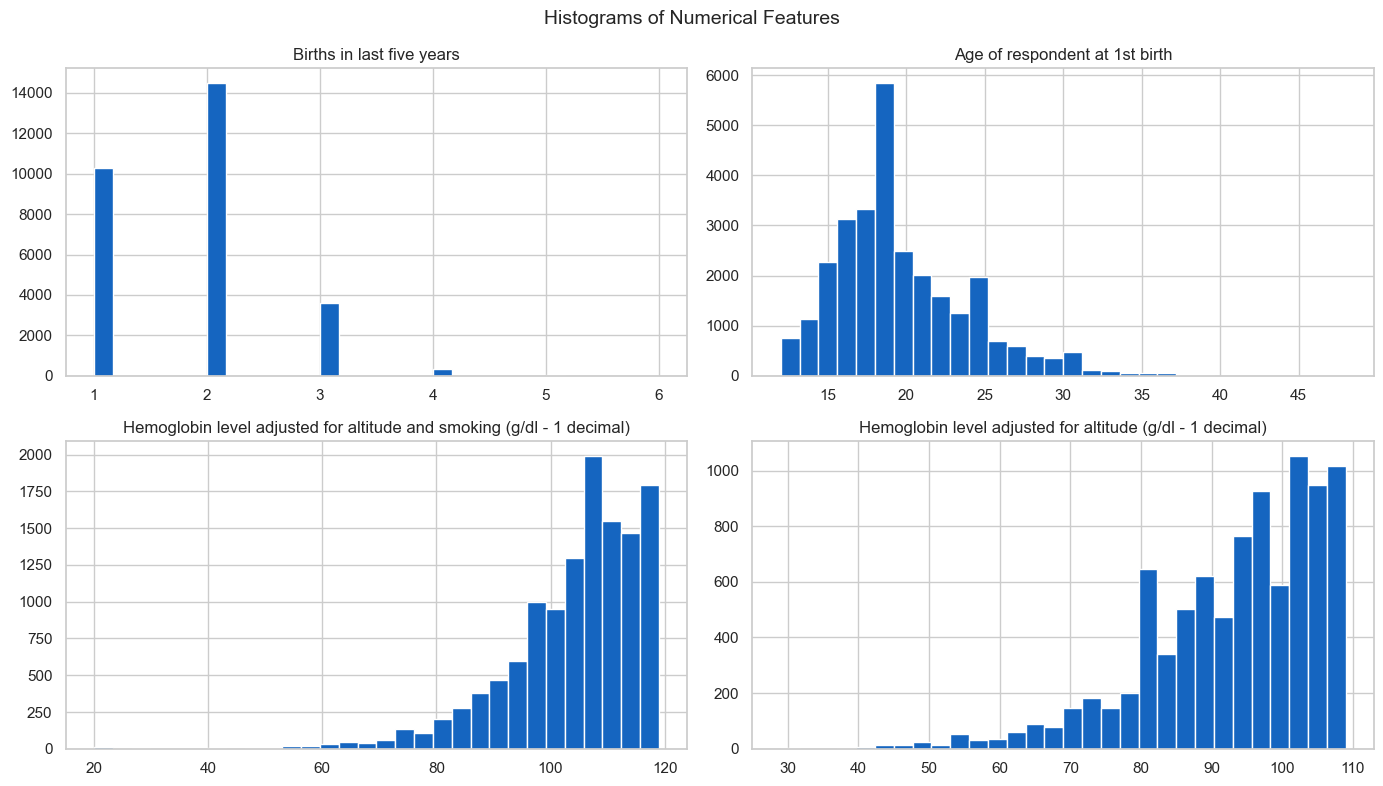

In [10]:
# i. Histograms for numeric distributions
df[numeric_cols].hist(figsize=(14, 8), bins=30, color="#1565C0", edgecolor="white")
plt.suptitle("Histograms of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

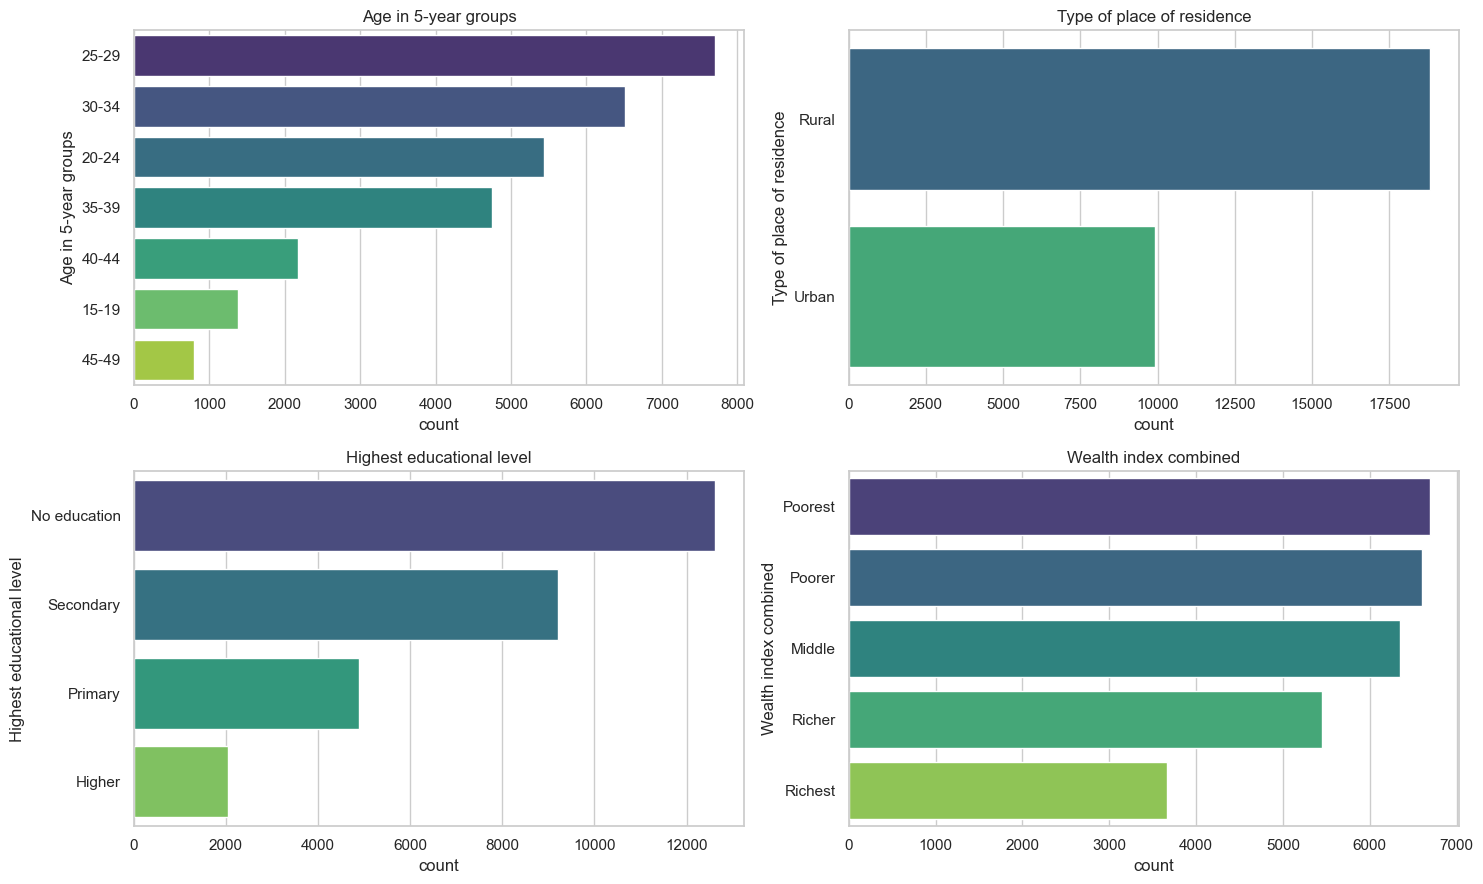

In [11]:
# ii & iii. Count plots / bar plots for key categorical features
key_cats = ["Age in 5-year groups", "Type of place of residence",
            "Highest educational level", "Wealth index combined"]
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, col in zip(axes.flatten(), key_cats):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=order, ax=ax, palette="viridis")
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [12]:
# iv. Grouped summary — mean haemoglobin by anemia level
hb_col = "Hemoglobin level adjusted for altitude and smoking (g/dl - 1 decimal)"
grouped = df.dropna(subset=["Anemia level"]).groupby("Anemia level")[hb_col].agg(
    ["mean", "median", "min", "max", "count"])
grouped

,mean,median,min,max,count
Anemia level,,,,,
Mild,112.994224,113.0,100.0,119.0,5540
Moderate,98.882966,101.0,70.0,109.0,6528
Severe,67.138614,70.0,20.0,79.0,404


### 2f. Target variable analysis

---

**🇸🇴 Sharraxaad Soomaali:**

### 2f. Falanqaynta doorsoomiyaha bartilmaameedka (target)

Waxaan eegaynaa qaybinta target-ka iyo xidhiidhkiisa astaamaha (tusaale: hemoglobin fasal kasta oo anemia).

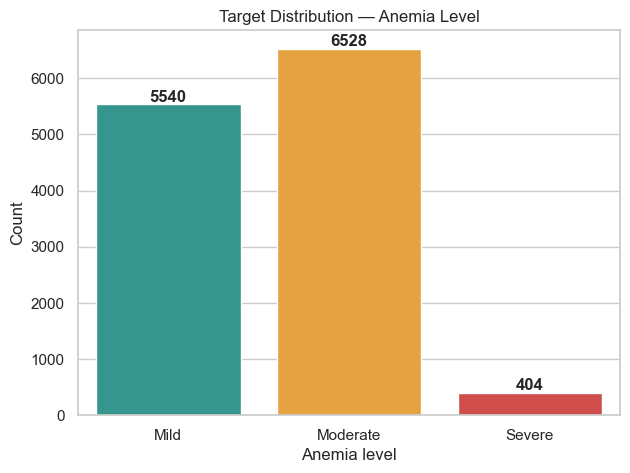

Anemia level
NaN         16282
Moderate     6528
Mild         5540
Severe        404
Name: count, dtype: int64


In [13]:
# i. Distribution of the target
plt.figure(figsize=(7, 5))
order = ["Mild", "Moderate", "Severe"]
sns.countplot(x="Anemia level", data=df, order=order,
              palette=["#26A69A", "#FFA726", "#E53935"])
plt.title("Target Distribution — Anemia Level")
plt.ylabel("Count")
for i, v in enumerate(df["Anemia level"].value_counts().reindex(order).values):
    plt.text(i, v + 40, str(int(v)), ha="center", fontweight="bold")
plt.show()

print(df["Anemia level"].value_counts(dropna=False))

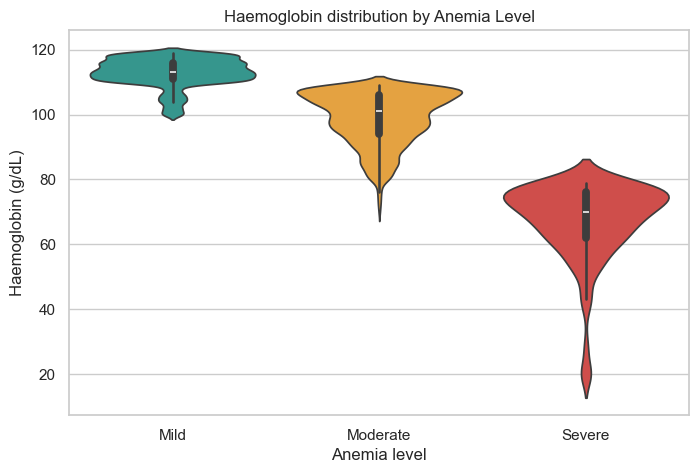

In [14]:
# ii. Relationship of target with haemoglobin (the clinical driver)
plt.figure(figsize=(8, 5))
sns.violinplot(x="Anemia level", y=hb_col, data=df.dropna(subset=["Anemia level"]),
               order=order, palette=["#26A69A", "#FFA726", "#E53935"])
plt.title("Haemoglobin distribution by Anemia Level")
plt.ylabel("Haemoglobin (g/dL)")
plt.show()

**EDA observations.**
- The target has three classes and is **highly imbalanced**: *Severe* is very rare
  (~404 cases) versus Mild/Moderate (thousands). This motivates **Step 13 (SMOTE)**.
- Haemoglobin separates the classes clearly (lower haemoglobin → more severe),
  confirming it is the strongest clinical predictor.
- Several columns contain missing values, handled next in **Step 3**.

---

**🇸🇴 Sharraxaad Soomaali:**

**Waxa EDA laga ogaaday.**
- Target-ku wuxuu leeyahay saddex fasal, waana **aad isku-dheelitirnaan-la'aan** (imbalanced): *Severe* aad bay u naadir tahay (~404 kiis) marka la barbardhigo Mild/Moderate (kumanyaal). Tani waxay sababtaa **Tallaabo 13 (SMOTE)**.
- Hemoglobin si cad ayuu u kala saaraa fasalada (hemoglobin hooseeya → anemia daran), taasoo xaqiijinaysa inuu yahay astaanta caafimaad ee ugu saadaalinta wanaagsan.
- Tiirar dhawr ah waxay leeyihiin qiyam maqan (missing values) — kuwaas oo lagu xalinayo **Tallaabo 3**.

## Step 3 — Data Cleaning

### 3a. Missing values

---

**🇸🇴 Sharraxaad Soomaali:**

## Tallaabo 3 — Nadiifinta Xogta

### 3a. Qiyamka maqan (missing values)

In [15]:
# i & ii. Check missing values
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values per column:")
print(missing)

Missing values per column:
Anemia level.1                                                           19768
Hemoglobin level adjusted for altitude (g/dl - 1 decimal)                19768
Hemoglobin level adjusted for altitude and smoking (g/dl - 1 decimal)    16282
Anemia level                                                             16282
When child put to breast                                                  9306
Had fever in last two weeks                                               2882
Taking iron pills, sprinkles or syrup                                     2882
Currently residing with husband/partner                                   1676
dtype: int64


**iii. Method chosen for missing values (with justification)**

1. **`Anemia level.1`** is a duplicate of the target column and is **dropped**
   (it would cause data leakage and adds no information).
2. Rows where the **target `Anemia level` is missing** are **dropped** — we cannot
   train or evaluate on rows with no label, and imputing a target is not valid.
3. Remaining **numeric** missing values → **median imputation** (median is robust to
   skew and outliers, so it does not distort the distribution).
4. Remaining **categorical** missing values → filled with the label **`"Unknown"`**
   (missingness can itself be informative, and this keeps every row usable instead
   of dropping more data).

---

**🇸🇴 Sharraxaad Soomaali:**

**iii. Habka loo doortay qiyamka maqan (iyo sababta)**

1. **`Anemia level.1`** waa nuqul ka mid ah tiirka target-ka, waana la **saaray** (wuxuu keeni karaa data leakage, faa'iidona ma laha).
2. Safafka ay ka maqan tahay **target-ka `Anemia level`** waa la **saaray** — ma tababari karno mana qiimeyn karno saf aan lahayn calaamad (label), qiyaasidda target-kuna sax maaha.
3. Qiyamka **tirooyinka** ee maqan → **qiyaasidda dhexe (median imputation)** (median-ku wuu adkeystaa skew iyo outliers, sidaas darteed qaybinta ma qalloociyo).
4. Qiyamka **qaybaha** ee maqan → waxaa lagu buuxiyay calaamadda **`"Unknown"`** (maqnaanshaha lafteedu macluumaad bay noqon kartaa, waxayna ilaalinaysaa saf kasta halkii aan xog badan laga tuuri lahaa).

In [16]:
# Apply the missing-value strategy
df_clean = df.copy()

# 1) drop leakage duplicate of the target
if "Anemia level.1" in df_clean.columns:
    df_clean = df_clean.drop(columns=["Anemia level.1"])

# 2) drop rows with no target label
before = df_clean.shape[0]
df_clean = df_clean.dropna(subset=["Anemia level"]).reset_index(drop=True)
print(f"Dropped {before - df_clean.shape[0]} rows with missing target.")
print("Rows remaining:", df_clean.shape[0])

# 3) numeric -> median imputation
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    if df_clean[c].isna().any():
        df_clean[c] = df_clean[c].fillna(df_clean[c].median())

# 4) categorical -> "Unknown"
cat_cols = [c for c in df_clean.select_dtypes(include=["object"]).columns
            if c != "Anemia level"]
for c in cat_cols:
    if df_clean[c].isna().any():
        df_clean[c] = df_clean[c].fillna("Unknown")

print("Missing values after cleaning:", int(df_clean.isna().sum().sum()))

Dropped 16282 rows with missing target.
Rows remaining: 12472
Missing values after cleaning: 0


### 3b. Removing duplicates

---

**🇸🇴 Sharraxaad Soomaali:**

### 3b. Ka-saarista nuqullada (duplicates)

Waan hubinaynaa safafka nuqul ah, haddii la helo waa la saaraa.

In [17]:
# i. Check duplicates
dups = df_clean.duplicated().sum()
print("Duplicate rows found:", dups)

# ii. Handle duplicates (drop if any)
if dups > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed. Rows now:", df_clean.shape[0])
else:
    print("No duplicates to remove.")

Duplicate rows found: 0
No duplicates to remove.


### 3c. Fixing inconsistent data entries

---

**🇸🇴 Sharraxaad Soomaali:**

### 3c. Saxitaanka gelinta xog aan is-waafaqsanayn

Waxaan ka saareynaa meelaha bannaan ee ku hareeraysan qoraalka qaybaha, si labo qaybood oo isku mid ah aanay u kala qaybsamin qaab-qoraal kala duwan awgeed.

In [18]:
# Strip stray whitespace from categorical text so identical categories are not
# split by formatting differences (e.g. "Rural " vs "Rural").
for c in cat_cols + ["Anemia level"]:
    df_clean[c] = df_clean[c].astype(str).str.strip()
print("Text columns trimmed. Example — Type of place of residence:")
print(df_clean["Type of place of residence"].unique())

Text columns trimmed. Example — Type of place of residence:
['Urban' 'Rural']


### 3d. Outlier detection and removal

---

**🇸🇴 Sharraxaad Soomaali:**

### 3d. Ogaanshaha & maaraynta outliers (qiyamka fog)

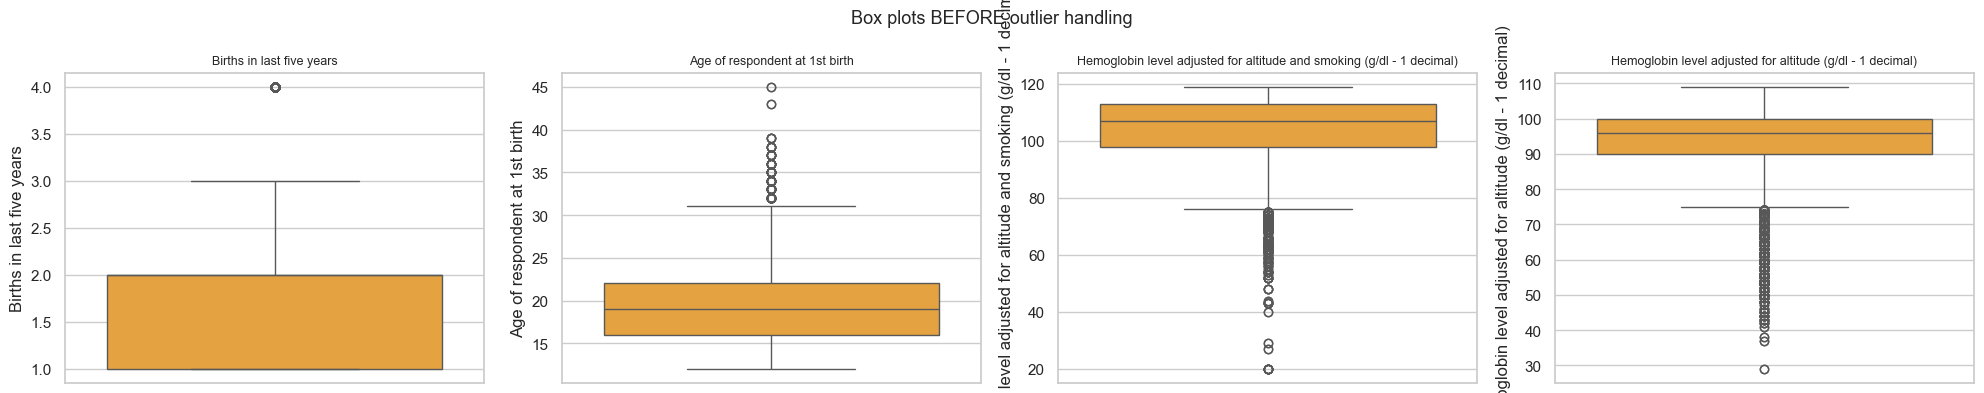

In [19]:
# i. Check outliers with box plots (numeric features)
fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
if len(num_cols) == 1:
    axes = [axes]
for ax, c in zip(axes, num_cols):
    sns.boxplot(y=df_clean[c], ax=ax, color="#FFA726")
    ax.set_title(c, fontsize=9)
plt.suptitle("Box plots BEFORE outlier handling", fontsize=13)
plt.tight_layout()
plt.show()

**ii & iii. Method chosen for outliers (with justification)**

We use the **IQR rule** (values below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR`).

- For the **demographic** numeric features (*Births in last five years*,
  *Age of respondent at 1st birth*) we **cap** (winsorize) outliers to the IQR
  bounds. Capping keeps the row (no data loss) while limiting the influence of
  extreme values.
- The **haemoglobin** features are **left unchanged on purpose**: extremely low
  haemoglobin is *not* a data error — it is exactly what defines a **Severe**
  anemia case. Removing or capping it would destroy the most important clinical
  signal, so these clinically-valid extremes are retained.

---

**🇸🇴 Sharraxaad Soomaali:**

**ii & iii. Habka loo doortay outliers (iyo sababta)**

Waxaan isticmaaleynaa **xeerka IQR** (qiyamka ka hooseeya `Q1 - 1.5*IQR` ama ka sareeya `Q3 + 1.5*IQR`).

- Astaamaha **demographic** ee tirooyinka (*Births in last five years*, *Age of respondent at 1st birth*) waxaan **xaddidaynaa** (cap/winsorize) outliers-ka ilaa xudduudaha IQR. Xaddiddu waxay ilaalisaa safka (xog ma lumin) iyadoo yaraynaysa saamaynta qiyamka fog.
- Astaamaha **hemoglobin** si ula kac ah ayaan **u daynay sidii ay ahaayeen**: hemoglobin aad u hooseeya ma aha qalad xog — waa waxa saxda ah ee qeexaya kiiska anemia **Severe**. Saaridiisa ama xaddiddiisu waxay burin lahayd astaanta caafimaad ee ugu muhiimsan, sidaas darteed qiyamkan xaqiiqada caafimaad ah waa la ilaaliyay.

In [20]:
# ii. Handle outliers — IQR capping on demographic numerics only
def iqr_cap(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series.clip(lower=low, upper=high), int(((series < low) | (series > high)).sum())

demographic_num = [c for c in ["Births in last five years",
                               "Age of respondent at 1st birth"] if c in df_clean.columns]
for c in demographic_num:
    df_clean[c], n = iqr_cap(df_clean[c])
    print(f"{c}: {n} outliers capped to IQR bounds.")
print("Haemoglobin columns retained unchanged (clinically valid extremes).")

Births in last five years: 180 outliers capped to IQR bounds.
Age of respondent at 1st birth: 128 outliers capped to IQR bounds.
Haemoglobin columns retained unchanged (clinically valid extremes).


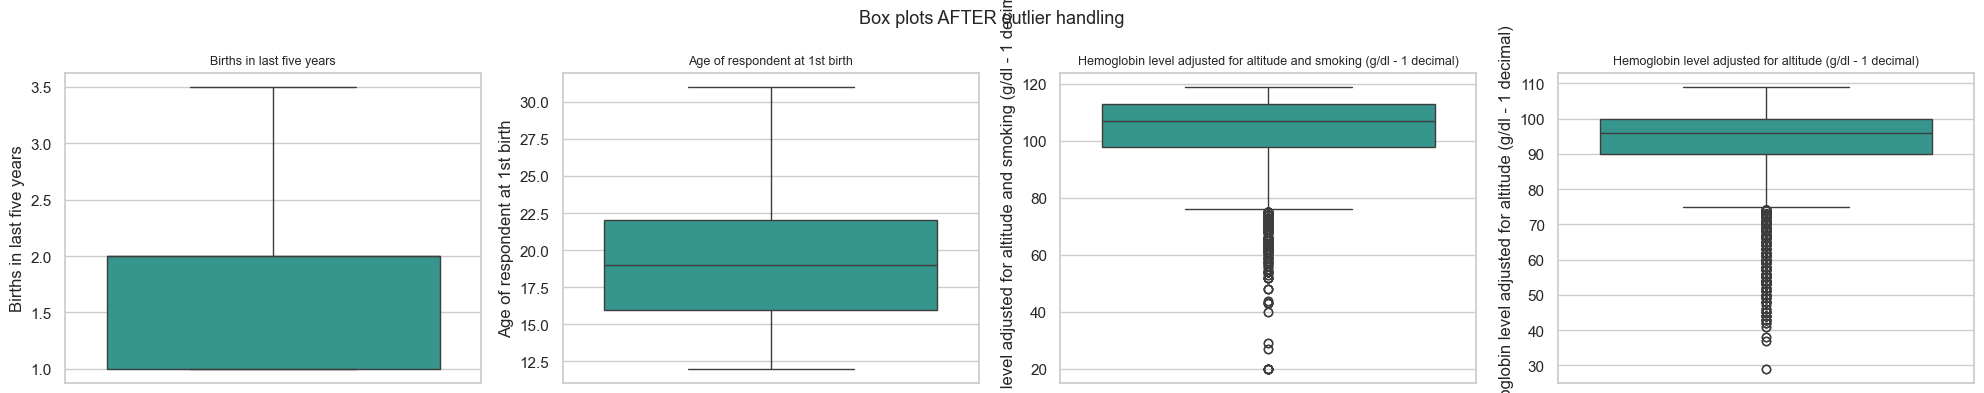

In [21]:
# iv. Check AFTER handling — box plots again
fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
if len(num_cols) == 1:
    axes = [axes]
for ax, c in zip(axes, num_cols):
    sns.boxplot(y=df_clean[c], ax=ax, color="#26A69A")
    ax.set_title(c, fontsize=9)
plt.suptitle("Box plots AFTER outlier handling", fontsize=13)
plt.tight_layout()
plt.show()

### 3e. Data transformation

**Method chosen (with justification).** Tree-based models (Random Forest, Decision
Tree, XGBoost) are **scale-invariant** and need no transformation. Distance/gradient
based models (Logistic Regression, SVM, KNN, MLP) *are* scale-sensitive, so for those
we apply **Standardization (Z-score)** inside a pipeline in Step 10 — this is applied
**after** the train/test split to avoid data leakage. Below we also demonstrate a
**log transformation** on the most skewed feature to show it reduces skewness.

---

**🇸🇴 Sharraxaad Soomaali:**

### 3e. Beddelka xogta (transformation)

**Habka loo doortay (iyo sababta).** Model-ada geedaha ku salaysan (Random Forest, Decision Tree, XGBoost) waa **cabbir-madax-bannaan**, beddelna uma baahna. Model-ada ku salaysan masaafada/gradient-ka (Logistic Regression, SVM, KNN, MLP) *waa* cabbir-xasaasi, sidaas darteed kuwaas waxaan ku dabaqaynaa **Standardization (Z-score)** gudaha pipeline Tallaabo 10 — kaas oo la sameeyo **ka dib** kala-qaybinta train/test si looga fogaado data leakage. Hoosna waxaan ku muujinaynaa **log transformation** astaanta ugu skew badan si loo tuso inay skew-ka yareyso.

Most skewed feature: Hemoglobin level adjusted for altitude and smoking (g/dl - 1 decimal) | skew = -1.55


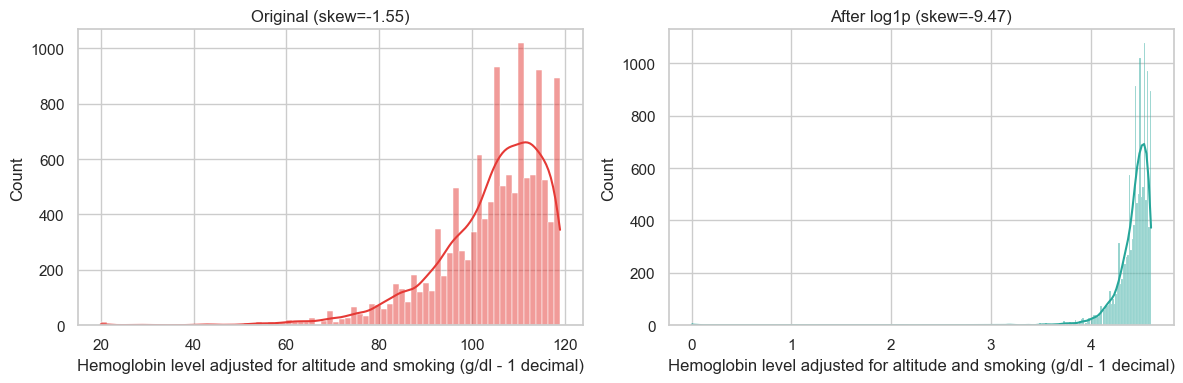

Note: log transform reduces skew; final scaling for sensitive models is done via pipeline in Step 10.


In [22]:
# Demonstrate log transformation on the most skewed numeric feature
skews = df_clean[num_cols].skew().abs().sort_values(ascending=False)
most_skewed = skews.index[0]
print("Most skewed feature:", most_skewed, "| skew =", round(df_clean[most_skewed].skew(), 3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_clean[most_skewed], kde=True, ax=ax[0], color="#E53935")
ax[0].set_title(f"Original (skew={df_clean[most_skewed].skew():.2f})")
logged = np.log1p(df_clean[most_skewed] - df_clean[most_skewed].min())
sns.histplot(logged, kde=True, ax=ax[1], color="#26A69A")
ax[1].set_title(f"After log1p (skew={logged.skew():.2f})")
plt.tight_layout()
plt.show()
print("Note: log transform reduces skew; final scaling for sensitive models is done via pipeline in Step 10.")

## Step 4 — Feature Engineering

We construct new, **non-leaking** demographic features from existing columns:
- **`young_mother`** — 1 if age at first birth < 18 (early childbearing, a known
  anemia risk factor).
- **`high_parity`** — 1 if births in last five years >= 3 (frequent pregnancies
  deplete iron stores).

(No date/time columns exist in this dataset, so date feature extraction is not
applicable.)

---

**🇸🇴 Sharraxaad Soomaali:**

## Tallaabo 4 — Abuurista Astaamo Cusub (Feature Engineering)

Waxaan ka dhisaynaa astaamo cusub oo **aan leakage lahayn** oo laga sameeyay tiirar jira:
- **`young_mother`** — 1 haddii da'da umusha koowaad ay ka yar tahay 18 (dhalmo hore, oo ah arrin khatar anemia sii kordhisa).
- **`high_parity`** — 1 haddii dhalmada 5-tii sano ay tahay >= 3 (uur badan oo isdaba-joog ah ayaa dhamaystiraya kaydka birta).

(Xogtan tiir taariikh/waqti ah ma lahan, sidaas darteed soo-saarista astaamaha taariikhda ma khusayso.)

In [23]:
if "Age of respondent at 1st birth" in df_clean.columns:
    df_clean["young_mother"] = ((df_clean["Age of respondent at 1st birth"] > 0) &
                                (df_clean["Age of respondent at 1st birth"] < 18)).astype(int)
if "Births in last five years" in df_clean.columns:
    df_clean["high_parity"] = (df_clean["Births in last five years"] >= 3).astype(int)

print("New features created: young_mother, high_parity")
print(df_clean[["young_mother", "high_parity"]].sum())

New features created: young_mother, high_parity
young_mother    4758
high_parity     1938
dtype: int64


## Step 5 — Feature Encoding

**Method chosen (with justification).**
- **Target `Anemia level`** → **Label Encoding** (Mild=0, Moderate=1, Severe=2).
  A single numeric target column is what scikit-learn classifiers expect.
- **Categorical features** → **One-Hot Encoding** (`pd.get_dummies`). These
  categories are mostly **nominal** (residence, marital status, source, etc.) with
  no natural order, so one-hot avoids imposing a false ordering that label encoding
  would introduce.

---

**🇸🇴 Sharraxaad Soomaali:**

## Tallaabo 5 — Encoding-ka Astaamaha

**Habka loo doortay (iyo sababta).**
- **Target `Anemia level`** → **Label Encoding** (Mild=0, Moderate=1, Severe=2). Hal tiir oo tiro ah ayaa ah waxa scikit-learn classifiers-ku doonayaan.
- **Astaamaha qaybaha** → **One-Hot Encoding** (`pd.get_dummies`). Qaybahani inta badan waa **nominal** (deegaan, xaalad guur, isha xogta, iwm.) oo aan lahayn kala-sarreyn dabiici ah, sidaas darteed one-hot wuxuu ka fogeeyaa kala-sarreyn been ah oo label encoding-gu keeni lahaa.

In [24]:
from sklearn.preprocessing import LabelEncoder

# Target: label encoding
le = LabelEncoder()
y = le.fit_transform(df_clean["Anemia level"])
print("Target classes (encoded):", dict(zip(le.classes_, le.transform(le.classes_))))

# Features: one-hot encode categoricals
X_raw = df_clean.drop(columns=["Anemia level"])
X = pd.get_dummies(X_raw)
print("Feature matrix after one-hot encoding:", X.shape)

Target classes (encoded): {'Mild': np.int64(0), 'Moderate': np.int64(1), 'Severe': np.int64(2)}
Feature matrix after one-hot encoding: (12472, 83)


## Step 6 — Feature Selection

---

**🇸🇴 Sharraxaad Soomaali:**

## Tallaabo 6 — Xulista Astaamaha (Feature Selection)

Waxaan isticmaaleynaa **correlation matrix (heatmap)** iyo **chi-square test** si aan u aqoonsanno astaamaha ugu saadaalinta xoogga badan.

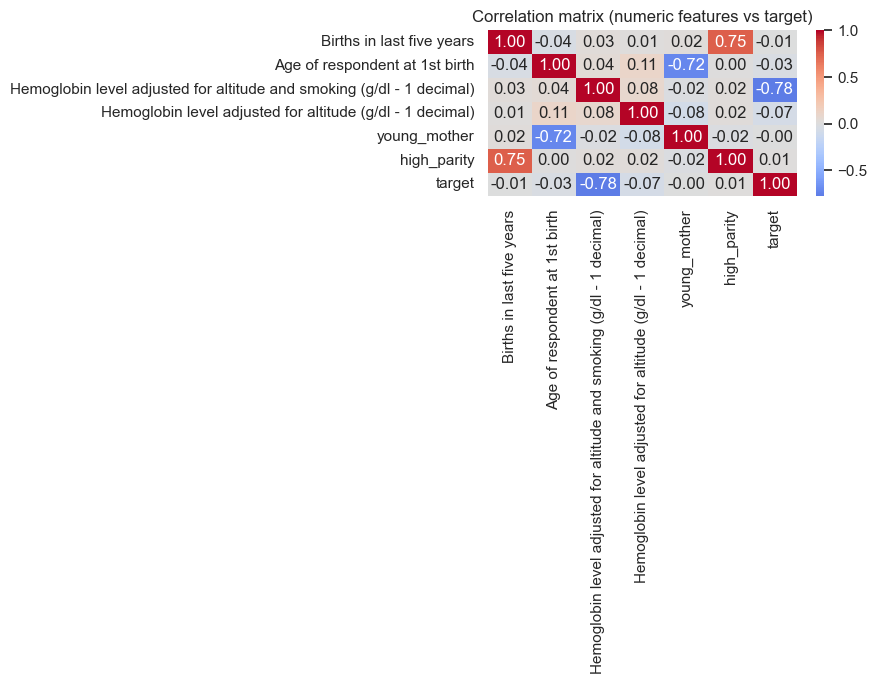

In [25]:
# i. Correlation matrix (numeric features) using a heatmap
corr_cols = num_cols + ["young_mother", "high_parity"]
corr_cols = [c for c in corr_cols if c in df_clean.columns]
plt.figure(figsize=(9, 7))
sns.heatmap(df_clean[corr_cols].assign(target=y).corr(),
            annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Correlation matrix (numeric features vs target)")
plt.tight_layout()
plt.show()

Top 15 features by chi-square score:
Hemoglobin level adjusted for altitude and smoking (g/dl - 1 decimal)    140.228464
Age in 5-year groups_45-49                                                31.074333
When child put to breast_Immediately                                      24.178382
Highest educational level_Higher                                          16.085943
Current marital status_Divorced                                           16.057086
When child put to breast_110.0                                            15.372518
Current marital status_Living with partner                                13.969541
When child put to breast_103.0                                            13.663594
Type of place of residence_Urban                                          13.368291
Wealth index combined_Richest                                             13.054829
Taking iron pills, sprinkles or syrup_Yes                                 12.322784
When child put to breast_105.0         

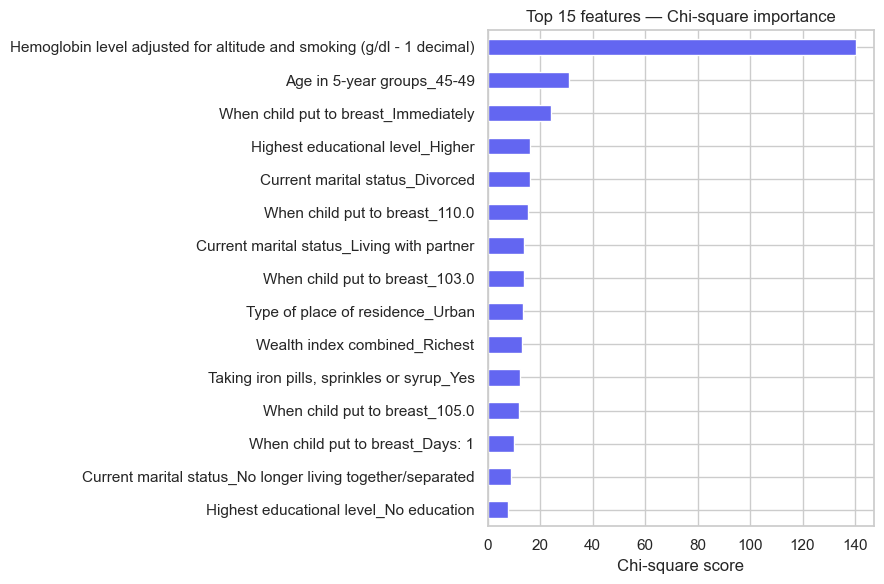

In [26]:
# ii. Chi-square test for classification (features vs target)
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

# chi2 needs non-negative features -> scale to [0,1]
X_scaled_chi = MinMaxScaler().fit_transform(X)
chi_selector = SelectKBest(score_func=chi2, k="all").fit(X_scaled_chi, y)
chi_scores = pd.Series(chi_selector.scores_, index=X.columns).sort_values(ascending=False)
print("Top 15 features by chi-square score:")
print(chi_scores.head(15))

plt.figure(figsize=(9, 6))
chi_scores.head(15).sort_values().plot(kind="barh", color="#6366F1")
plt.title("Top 15 features — Chi-square importance")
plt.xlabel("Chi-square score")
plt.tight_layout()
plt.show()

## Step 7 — Constructing Predictive Features

The final predictive feature set combines: the cleaned original features, the
one-hot encoded categoricals (Step 5), and the engineered features `young_mother`
and `high_parity` (Step 4). The chi-square analysis (Step 6) confirms the
haemoglobin features and key demographics carry the strongest signal. We keep the
full encoded feature set so every model can use all available information.

---

**🇸🇴 Sharraxaad Soomaali:**

## Tallaabo 7 — Dhisidda Astaamaha Saadaalinta

Astaamaha kama dambaysta ah waxay isku daraan: astaamihii asalka ahaa ee la nadiifiyay, qaybaha one-hot ee la encode-gareeyay (Tallaabo 5), iyo astaamaha la abuuray `young_mother` iyo `high_parity` (Tallaabo 4). Falanqaynta chi-square (Tallaabo 6) waxay xaqiijisaa in hemoglobin iyo demographics-ka muhiimka ah ay sitaan astaanta ugu xooggan. Waxaan hayneynaa dhammaan astaamaha si model kastaa u isticmaalo dhammaan macluumaadka la heli karo.

In [27]:
X = X.fillna(0)
print("Final predictive feature matrix:", X.shape)
print("Target vector:", y.shape)

Final predictive feature matrix: (12472, 83)
Target vector: (12472,)


## Step 8 — Data Splitting

We split **80% train / 20% test** with **stratification** on the target, so the rare
*Severe* class keeps the same proportion in both sets. `random_state=42` makes the
split reproducible.

---

**🇸🇴 Sharraxaad Soomaali:**

## Tallaabo 8 — Kala-qaybinta Xogta

Waxaan u kala qaybineynaa **80% train / 20% test** iyadoo la isticmaalayo **stratification** target-ka, si fasalka naadirka ah ee *Severe* uu isku qiyaas ugu jiro labada qaybood. `random_state=42` wuxuu ka dhigayaa kala-qaybinta mid dib loo soo celin karo (reproducible).

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train class counts:", np.bincount(y_train))
print("Test  class counts:", np.bincount(y_test))

Train: (9977, 83) | Test: (2495, 83)
Train class counts: [4432 5222  323]
Test  class counts: [1108 1306   81]


## Step 9 — Baseline Method for Benchmarking

A **DummyClassifier** provides the naive benchmark that any real model must beat.
We report both the *most-frequent* and *stratified* strategies.

---

**🇸🇴 Sharraxaad Soomaali:**

## Tallaabo 9 — Habka Aasaasiga ah ee Isbarbardhigga (Baseline)

**DummyClassifier** wuxuu bixiyaa cabbirka aasaasiga ah ee model kasta oo dhab ah uu ka sarreeyo. Waxaan soo bandhigaynaa labada hab: *most-frequent* iyo *stratified*.

In [29]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

for strat in ["most_frequent", "stratified"]:
    dummy = DummyClassifier(strategy=strat, random_state=RANDOM_STATE)
    dummy.fit(X_train, y_train)
    p = dummy.predict(X_test)
    print(f"Baseline ({strat:>13}): accuracy={accuracy_score(y_test, p):.4f} | "
          f"macro-F1={f1_score(y_test, p, average='macro'):.4f}")

Baseline (most_frequent): accuracy=0.5234 | macro-F1=0.2291
Baseline (   stratified): accuracy=0.4693 | macro-F1=0.3251


## Step 10 — Train Machine-Learning Models (8 models)

We train **8 algorithms**. Scale-sensitive models (Logistic Regression, SVM, KNN,
MLP) are wrapped in a `StandardScaler` pipeline; tree/boosting/NB models are used
directly.

---

**🇸🇴 Sharraxaad Soomaali:**

## Tallaabo 10 — Tababarka Model-ada Machine Learning (8 model)

Waxaan tababaraynaa **8 algorithm**. Model-ada cabbir-xasaasiga ah (Logistic Regression, SVM, KNN, MLP) waxaa lagu duubay `StandardScaler` pipeline; model-ada geedaha/boosting/NB si toos ah ayaa loo isticmaalaa.

In [30]:
import time
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report

models = {
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss",
                             n_estimators=200, verbosity=0),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": make_pipeline(StandardScaler(with_mean=False),
                                         LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    "SVM": make_pipeline(StandardScaler(with_mean=False), SVC(random_state=RANDOM_STATE)),
    "KNN": make_pipeline(StandardScaler(with_mean=False), KNeighborsClassifier()),
    "Neural Network (MLP)": make_pipeline(StandardScaler(with_mean=False),
                                          MLPClassifier(hidden_layer_sizes=(64, 32),
                                                        max_iter=300, random_state=RANDOM_STATE)),
}

rows, preds = [], {}
for name, model in models.items():
    print(f"Training {name} ...", end=" ", flush=True)
    t0 = time.time()
    model.fit(X_train, y_train)
    dt = time.time() - t0
    yp = model.predict(X_test)
    preds[name] = yp
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, yp),
        "Precision (weighted)": precision_score(y_test, yp, average="weighted", zero_division=0),
        "Recall (weighted)": recall_score(y_test, yp, average="weighted", zero_division=0),
        "F1 (weighted)": f1_score(y_test, yp, average="weighted", zero_division=0),
        "F1 (macro)": f1_score(y_test, yp, average="macro", zero_division=0),
        "Train time (s)": round(dt, 2),
    })
    print(f"done ({dt:.1f}s, acc={rows[-1]['Accuracy']:.4f})")

results = pd.DataFrame(rows).sort_values("F1 (macro)", ascending=False).reset_index(drop=True)
results.insert(0, "Rank", range(1, len(results) + 1))
results

Training Random Forest ... 

done (0.8s, acc=0.9583)
Training XGBoost ... 

done (1.0s, acc=0.9812)
Training Decision Tree ... 

done (0.0s, acc=0.9776)
Training Naive Bayes ... 

done (0.0s, acc=0.0453)
Training Logistic Regression ... 

done (1.2s, acc=0.8930)
Training SVM ... 

done (6.5s, acc=0.8725)
Training KNN ... 

done (0.0s, acc=0.7242)
Training Neural Network (MLP) ... 

done (16.3s, acc=0.9463)


,Rank,Model,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro),Train time (s)
0,1,XGBoost,0.981162,0.981267,0.981162,0.981167,0.975626,1.03
1,2,Decision Tree,0.977555,0.977576,0.977555,0.977561,0.973131,0.05
2,3,Random Forest,0.958317,0.960704,0.958317,0.958184,0.954854,0.84
3,4,Neural Network (MLP),0.946293,0.946596,0.946293,0.946227,0.949864,16.26
4,5,Logistic Regression,0.892986,0.892984,0.892986,0.892984,0.897332,1.24
5,6,SVM,0.872545,0.875081,0.872545,0.869469,0.775222,6.48
6,7,KNN,0.724248,0.729533,0.724248,0.720549,0.627121,0.03
7,8,Naive Bayes,0.045291,0.574717,0.045291,0.027604,0.039727,0.03


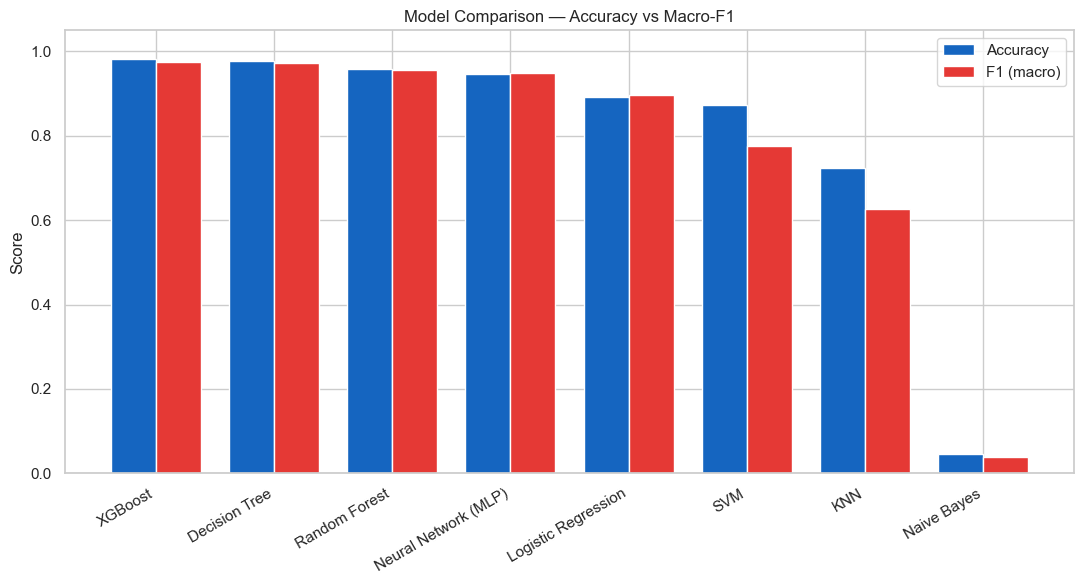

In [31]:
# Chart: Accuracy vs Macro-F1 for all 8 models
fig, ax = plt.subplots(figsize=(11, 6))
xpos = np.arange(len(results)); w = 0.38
ax.bar(xpos - w/2, results["Accuracy"], w, label="Accuracy", color="#1565C0")
ax.bar(xpos + w/2, results["F1 (macro)"], w, label="F1 (macro)", color="#E53935")
ax.set_xticks(xpos); ax.set_xticklabels(results["Model"], rotation=30, ha="right")
ax.set_ylim(0, 1.05); ax.set_ylabel("Score")
ax.set_title("Model Comparison — Accuracy vs Macro-F1"); ax.legend()
plt.tight_layout(); plt.show()

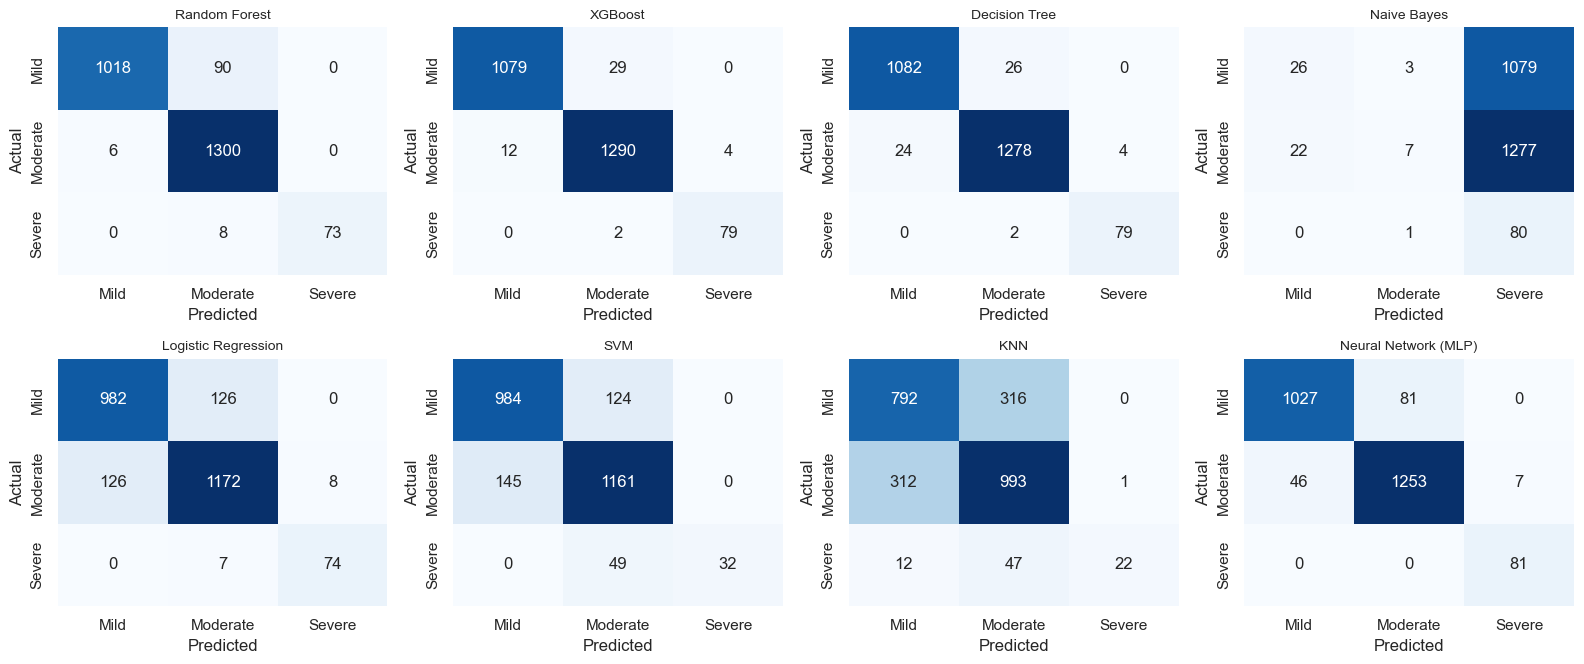

In [32]:
# Confusion matrices for all 8 models
classes = list(le.classes_)
n = len(preds); cols = 4; rws = (n + cols - 1) // cols
fig, axes = plt.subplots(rws, cols, figsize=(4*cols, 3.4*rws))
axes = axes.flatten()
for ax, (name, yp) in zip(axes, preds.items()):
    sns.heatmap(confusion_matrix(y_test, yp), annot=True, fmt="d", cmap="Blues",
                cbar=False, xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(name, fontsize=10); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
for ax in axes[n:]:
    ax.axis("off")
plt.tight_layout(); plt.show()

## Step 11 — Hyperparameter Tuning & Model Selection

We tune the two strongest tree/boosting models (**XGBoost** and **Random Forest**)
with `GridSearchCV` (3-fold, scoring = macro-F1, which is appropriate for the
imbalanced target).

---

**🇸🇴 Sharraxaad Soomaali:**

## Tallaabo 11 — Habaynta Hyperparameter & Xulista Model-ka

Waxaan habaynaynaa labada model ee geedaha/boosting ee ugu xooggan (**XGBoost** iyo **Random Forest**) iyadoo la isticmaalayo `GridSearchCV` (3-fold, cabbir = macro-F1, kaas oo ku habboon target-ka isku-dheelitirnaan-la'aanta leh).

In [33]:
from sklearn.model_selection import GridSearchCV

xgb_grid = {
    "n_estimators": [200, 300],
    "max_depth": [4, 6],
    "learning_rate": [0.1, 0.3],
}
gs_xgb = GridSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", verbosity=0),
    xgb_grid, cv=3, scoring="f1_macro", n_jobs=-1)
gs_xgb.fit(X_train, y_train)
print("XGBoost best params:", gs_xgb.best_params_)
print("XGBoost best CV macro-F1:", round(gs_xgb.best_score_, 4))

XGBoost best params: {'learning_rate': 0.3, 'max_depth': 6, 'n_estimators': 300}
XGBoost best CV macro-F1: 0.9688


In [34]:
rf_grid = {
    "n_estimators": [200, 300],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5],
}
gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_grid, cv=3, scoring="f1_macro", n_jobs=-1)
gs_rf.fit(X_train, y_train)
print("Random Forest best params:", gs_rf.best_params_)
print("Random Forest best CV macro-F1:", round(gs_rf.best_score_, 4))

Random Forest best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Random Forest best CV macro-F1: 0.9176


## Step 12 — Select Best Model & Evaluate

---

**🇸🇴 Sharraxaad Soomaali:**

## Tallaabo 12 — Xulista Model-ka Ugu Fiican & Qiimaynta

Waxaan is-barbardhigaynaa model-ada la habeeyay, kadibna waxaan doorannaa kan ugu macro-F1 sarreeya, waxaana lagu qiimeeyaa classification report, confusion matrix, iyo per-class F1.

In [35]:
# Compare tuned candidates on the test set
candidates = {
    "XGBoost (tuned)": gs_xgb.best_estimator_,
    "Random Forest (tuned)": gs_rf.best_estimator_,
}
best_name, best_model, best_f1 = None, None, -1
for name, model in candidates.items():
    yp = model.predict(X_test)
    f1m = f1_score(y_test, yp, average="macro")
    acc = accuracy_score(y_test, yp)
    print(f"{name}: accuracy={acc:.4f} | macro-F1={f1m:.4f}")
    if f1m > best_f1:
        best_f1, best_name, best_model = f1m, name, model

print("\nSelected best model:", best_name)

XGBoost (tuned): accuracy=0.9812 | macro-F1=0.9756
Random Forest (tuned): accuracy=0.9571 | macro-F1=0.9519

Selected best model: XGBoost (tuned)


Classification report — XGBoost (tuned)
              precision    recall  f1-score   support

        Mild       0.99      0.98      0.98      1108
    Moderate       0.98      0.99      0.98      1306
      Severe       0.95      0.98      0.96        81

    accuracy                           0.98      2495
   macro avg       0.97      0.98      0.98      2495
weighted avg       0.98      0.98      0.98      2495



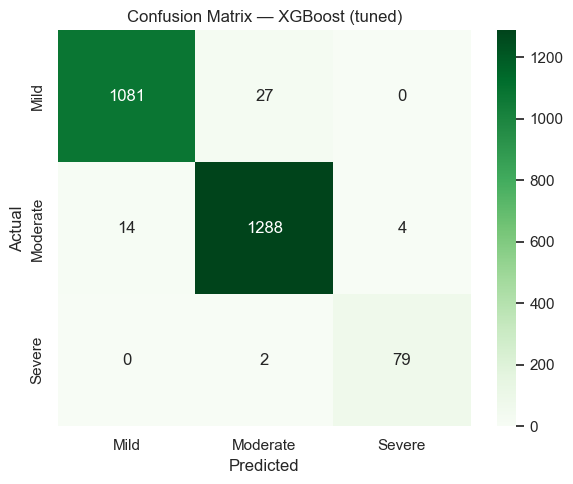

In [36]:
# Detailed evaluation of the best model
y_pred_best = best_model.predict(X_test)
print("Classification report —", best_name)
print(classification_report(y_test, y_pred_best, target_names=classes, zero_division=0))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt="d", cmap="Greens",
            xticklabels=classes, yticklabels=classes)
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout(); plt.show()

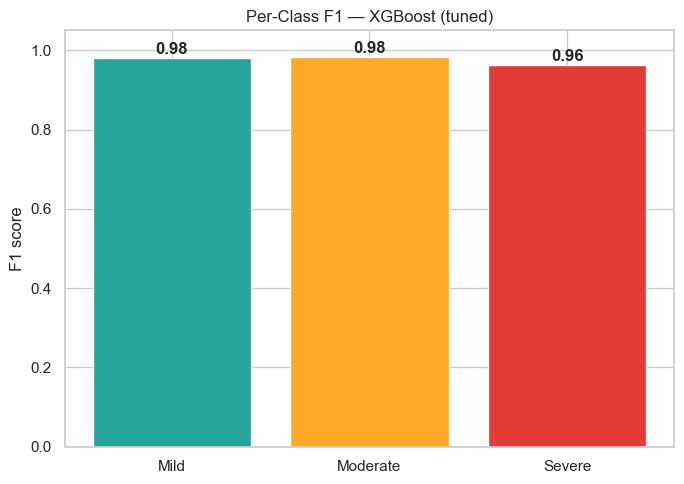

In [37]:
# Per-class F1 for the best model
f1s = f1_score(y_test, y_pred_best, average=None, zero_division=0)
plt.figure(figsize=(7, 5))
plt.bar(classes, f1s, color=["#26A69A", "#FFA726", "#E53935"])
plt.ylim(0, 1.05); plt.ylabel("F1 score"); plt.title(f"Per-Class F1 — {best_name}")
for i, v in enumerate(f1s):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

## Step 13 — Mitigate the Imbalanced-Class Problem (SMOTE)

The *Severe* class is severely under-represented. We apply **SMOTE** (Synthetic
Minority Over-sampling TEchnique) to the **training set only** (never the test set,
to avoid leakage), then retrain the best model and compare — focusing on the
**recall of the Severe class**, which matters most clinically.

---

**🇸🇴 Sharraxaad Soomaali:**

## Tallaabo 13 — Xallinta Dhibaatada Isku-dheelitirnaan-la'aanta (SMOTE)

Fasalka *Severe* aad buu u yar yahay. Waxaan ku dabaqaynaa **SMOTE** (Synthetic Minority Over-sampling TEchnique) **kaliya xogta tababarka** (marnaba test-ka, si looga fogaado leakage), kadibna waxaan dib u tababaraynaa model-ka ugu fiican oo aan is-barbardhigaynaa — iyadoo la diiradda saarayo **recall-ka fasalka Severe**, kaas oo caafimaad ahaan ugu muhiimsan.

In [38]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE — train class counts:", np.bincount(y_train))
sm = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print("After  SMOTE — train class counts:", np.bincount(y_train_sm))

Before SMOTE — train class counts: [4432 5222  323]
After  SMOTE — train class counts: [5222 5222 5222]


In [39]:
# Retrain the best model type on SMOTE-balanced data
from sklearn.base import clone
best_smote = clone(best_model)
best_smote.fit(X_train_sm, y_train_sm)
y_pred_sm = best_smote.predict(X_test)

print("=== BEFORE SMOTE ===")
print(classification_report(y_test, y_pred_best, target_names=classes, zero_division=0))
print("=== AFTER SMOTE ===")
print(classification_report(y_test, y_pred_sm, target_names=classes, zero_division=0))

=== BEFORE SMOTE ===
              precision    recall  f1-score   support

        Mild       0.99      0.98      0.98      1108
    Moderate       0.98      0.99      0.98      1306
      Severe       0.95      0.98      0.96        81

    accuracy                           0.98      2495
   macro avg       0.97      0.98      0.98      2495
weighted avg       0.98      0.98      0.98      2495

=== AFTER SMOTE ===
              precision    recall  f1-score   support

        Mild       0.99      0.98      0.98      1108
    Moderate       0.98      0.99      0.98      1306
      Severe       0.98      0.98      0.98        81

    accuracy                           0.98      2495
   macro avg       0.98      0.98      0.98      2495
weighted avg       0.98      0.98      0.98      2495



       Metric  Before SMOTE  After SMOTE
Severe recall      0.975309     0.975309
     Macro-F1      0.975628     0.980408
     Accuracy      0.981162     0.982766


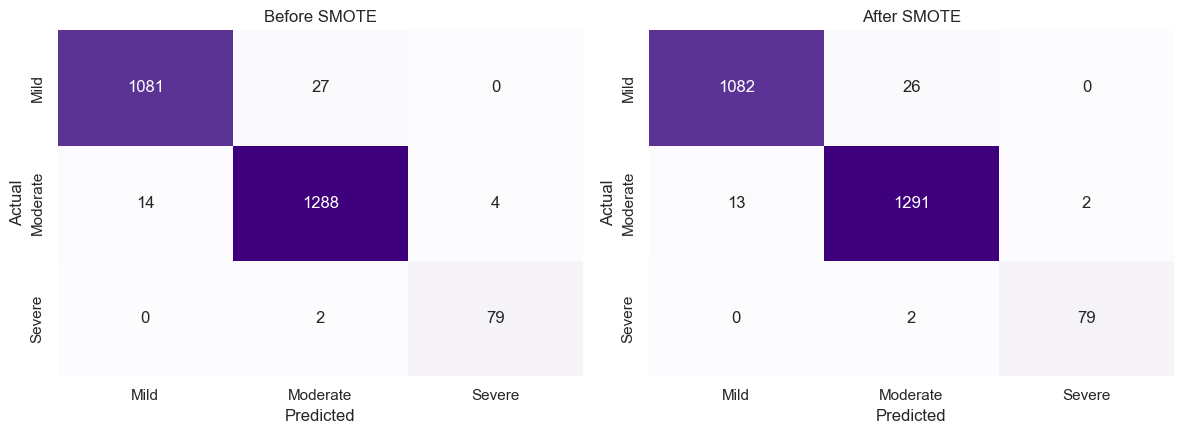

In [40]:
# Compare Severe-class recall before vs after SMOTE
sev = list(classes).index("Severe")
rec_before = recall_score(y_test, y_pred_best, average=None, zero_division=0)[sev]
rec_after = recall_score(y_test, y_pred_sm, average=None, zero_division=0)[sev]
macro_before = f1_score(y_test, y_pred_best, average="macro")
macro_after = f1_score(y_test, y_pred_sm, average="macro")

comp = pd.DataFrame({
    "Metric": ["Severe recall", "Macro-F1", "Accuracy"],
    "Before SMOTE": [rec_before, macro_before, accuracy_score(y_test, y_pred_best)],
    "After SMOTE": [rec_after, macro_after, accuracy_score(y_test, y_pred_sm)],
})
print(comp.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for a, (name, yp) in zip(ax, [("Before SMOTE", y_pred_best), ("After SMOTE", y_pred_sm)]):
    sns.heatmap(confusion_matrix(y_test, yp), annot=True, fmt="d", cmap="Purples",
                xticklabels=classes, yticklabels=classes, ax=a, cbar=False)
    a.set_title(name); a.set_xlabel("Predicted"); a.set_ylabel("Actual")
plt.tight_layout(); plt.show()

## Conclusion & Saving the Final Model

- All **13 pipeline steps** were completed in order: from EDA and cleaning through
  encoding, feature selection, an 8-model comparison, hyperparameter tuning, and
  finally class-imbalance mitigation with SMOTE.
- **Eight models** were trained and benchmarked; the best model was selected by
  macro-F1 after tuning.
- **SMOTE** improved detection of the rare **Severe** class, which is the most
  clinically important outcome.

---

**🇸🇴 Sharraxaad Soomaali:**

## Gunaanad & Keydinta Model-ka Kama-dambaysta ah

- Dhammaan **13-ka tallaabo** waa la dhammaystiray si isku xigxiga: laga bilaabo EDA iyo nadiifinta, ilaa encoding, xulista astaamaha, is-barbardhigga 8-da model, habaynta hyperparameter, iyo ugu dambayn xallinta isku-dheelitirnaan-la'aanta ee SMOTE.
- **Siddeed model** ayaa la tababaray oo la cabbiray; kan ugu fiican waxaa lagu doortay macro-F1 ka dib habaynta.
- **SMOTE** wuxuu hagaajiyay ogaanshaha fasalka naadirka ah ee **Severe**, kaas oo ah natiijada caafimaad ahaan ugu muhiimsan.

In [41]:
import joblib
joblib.dump(best_smote, "final_model_pipeline.pkl")
joblib.dump(le, "final_label_encoder.pkl")
joblib.dump(list(X.columns), "final_model_columns.pkl")
print("Saved: final_model_pipeline.pkl, final_label_encoder.pkl, final_model_columns.pkl")
print("Pipeline complete — all 13 steps executed.")

Saved: final_model_pipeline.pkl, final_label_encoder.pkl, final_model_columns.pkl
Pipeline complete — all 13 steps executed.
